In [2]:
import sqlite3
import pandas as pd
import json
import matplotlib.pyplot as plt
from pathlib import Path

db_path = Path.home() / ".cache/huggingface/trackio/huggingface.db"
conn = sqlite3.connect(db_path)

# metrics 테이블 불러오기
df = pd.read_sql("SELECT * FROM metrics", conn)

# metrics 컬럼을 JSON으로 변환
def parse_metrics(x):
    if isinstance(x, (bytes, bytearray)):
        x = x.decode("utf-8")
    return json.loads(x)

df["parsed"] = df["metrics"].apply(parse_metrics)

# JSON을 개별 컬럼으로 펼치기
metrics_expanded = pd.json_normalize(df["parsed"])
df = pd.concat([df, metrics_expanded], axis=1)

print(df.head())

OperationalError: unable to open database file

Runs found: ['dainty-sunset-0' 'brave-forest-1' 'calm-river-2']


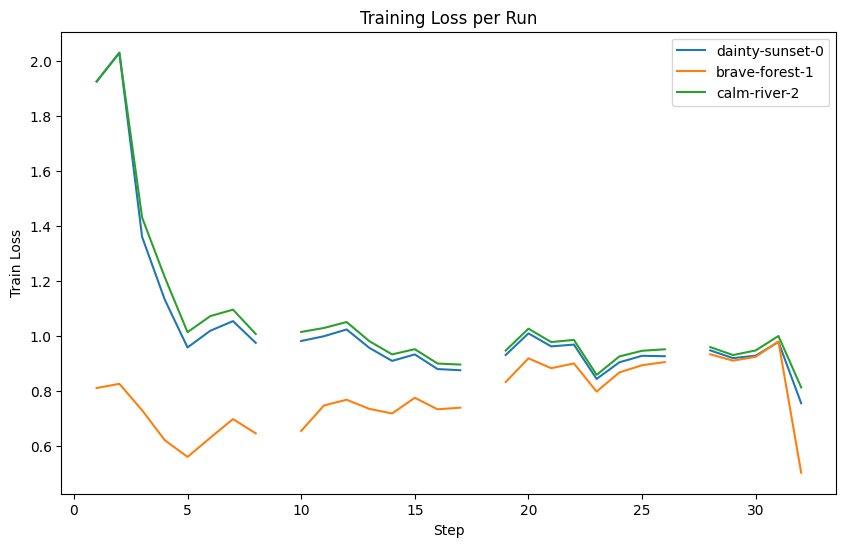

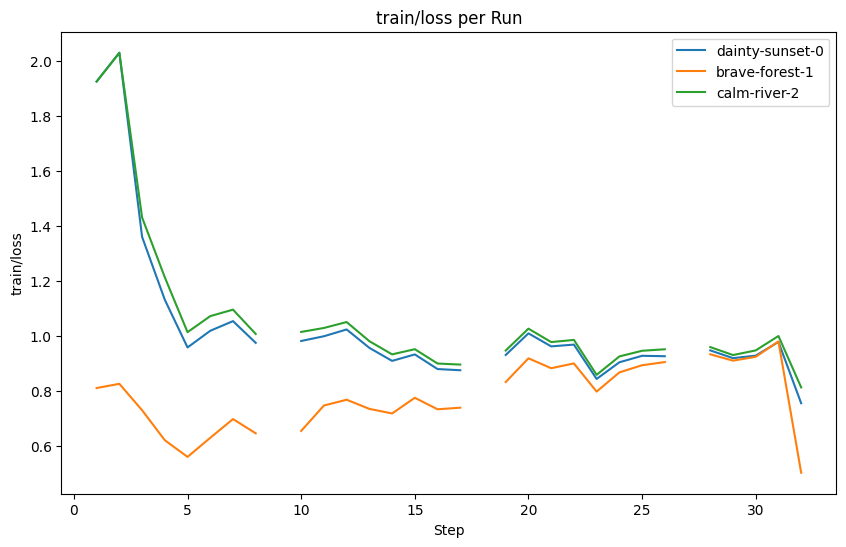

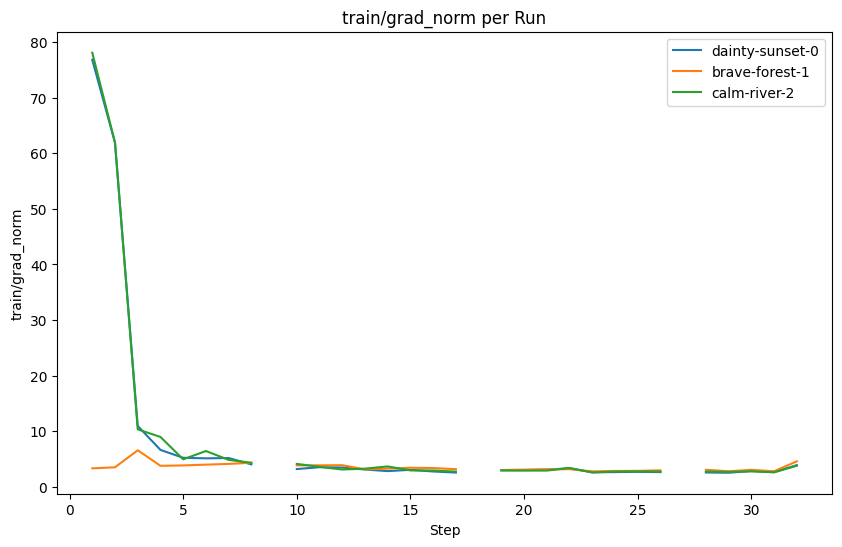

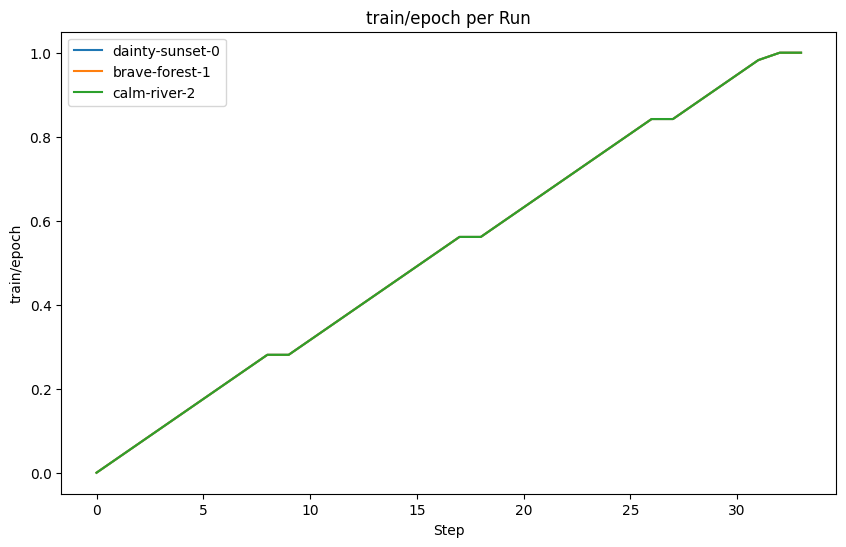

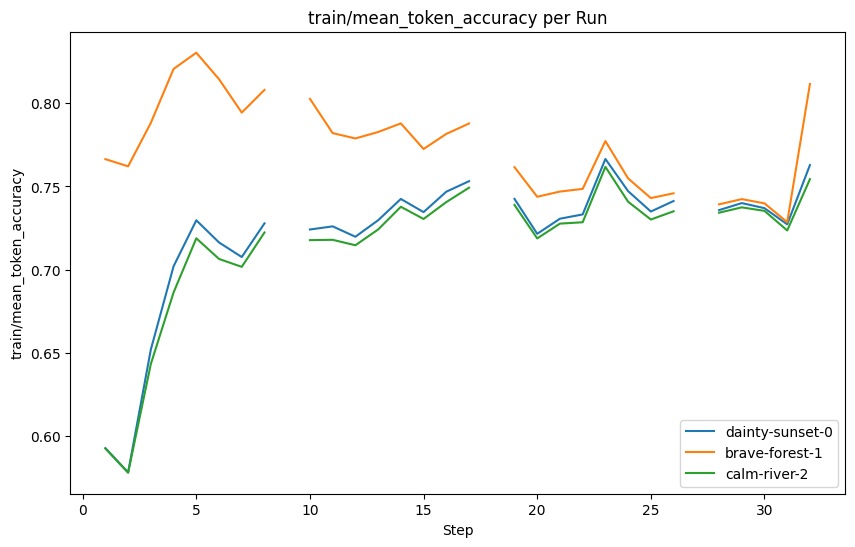

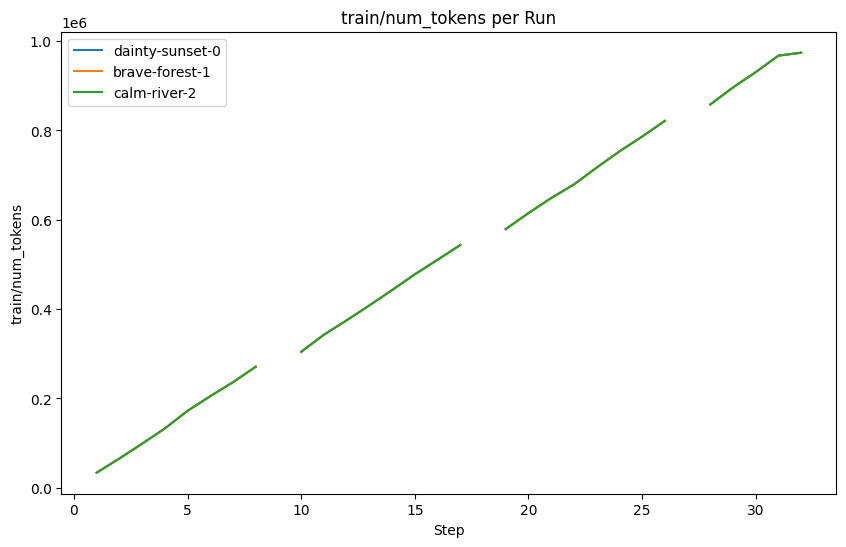

In [23]:
# run_name 기준으로 그룹 나누기
runs = df["run_name"].unique()
print("Runs found:", runs)

# 예시: train/loss 그래프 run_name 별로 그리기
plt.figure(figsize=(10,6))
for run in runs:
    sub = df[df["run_name"] == run].reset_index(drop=True)
    if "train/loss" in sub:
        plt.plot(sub.index, sub["train/loss"], label=f"{run}")

plt.xlabel("Step")
plt.ylabel("Train Loss")
plt.title("Training Loss per Run")
plt.legend()
plt.show()


# 여러 메트릭을 각각 그려보고 싶으면 반복
metrics_to_plot = ["train/loss", "train/grad_norm", "train/epoch", "train/mean_token_accuracy", "train/num_tokens"]
for metric in metrics_to_plot:
    if metric in df:
        plt.figure(figsize=(10,6))
        for run in runs:
            sub = df[df["run_name"] == run].reset_index(drop=True)
            plt.plot(sub.index, sub[metric], label=f"{run}")
        plt.xlabel("Step")
        plt.ylabel(metric)
        plt.title(f"{metric} per Run")
        plt.legend()
        plt.show()

In [22]:
df

,id,timestamp,run_name,step,metrics,parsed,eval/loss,eval/runtime,eval/samples_per_second,eval/steps_per_second,...,gpu/6/memory_usage,gpu/7/allocated_memory,gpu/7/memory_usage,train/global_step,train/loss,train/grad_norm,train/learning_rate,train/entropy,train/num_tokens,train/mean_token_accuracy
0,1,2025-09-29T16:57:21.276205,dainty-sunset-0,0,"b'{""eval/loss"":2.0484910011291504,""eval/runtim...","{'eval/loss': 2.0484910011291504, 'eval/runtim...",2.048491,7.3293,13.644,0.955,...,0.146273,20.450631,0.146273,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2025-09-29T16:57:35.861809,dainty-sunset-0,1,"b'{""train/loss"":1.9239,""train/grad_norm"":76.80...","{'train/loss': 1.9239, 'train/grad_norm': 76.8...",NaN,NaN,NaN,NaN,...,0.285827,39.961911,0.285827,1,1.9239,76.804054,0.000000,1.417121,33651.0,0.592793
2,3,2025-09-29T16:57:43.989246,dainty-sunset-0,2,"b'{""train/loss"":2.0285,""train/grad_norm"":61.86...","{'train/loss': 2.0285, 'train/grad_norm': 61.8...",NaN,NaN,NaN,NaN,...,0.285827,39.961944,0.285827,2,2.0285,61.864319,0.000020,1.346952,65452.0,0.578220
3,4,2025-09-29T16:57:51.112462,dainty-sunset-0,3,"b'{""train/loss"":1.3589,""train/grad_norm"":10.94...","{'train/loss': 1.3589, 'train/grad_norm': 10.9...",NaN,NaN,NaN,NaN,...,0.285827,39.961951,0.285827,3,1.3589,10.943837,0.000020,1.468865,98595.0,0.652072
4,5,2025-09-29T16:57:58.688176,dainty-sunset-0,4,"b'{""train/loss"":1.1301,""train/grad_norm"":6.631...","{'train/loss': 1.1301, 'train/grad_norm': 6.63...",NaN,NaN,NaN,NaN,...,0.285827,39.961889,0.285827,4,1.1301,6.631423,0.000020,1.115265,132717.0,0.702054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,98,2025-09-30T13:03:19.141245,calm-river-2,29,"b'{""train/loss"":0.929,""train/grad_norm"":2.6761...","{'train/loss': 0.929, 'train/grad_norm': 2.676...",NaN,NaN,NaN,NaN,...,0.285831,39.961987,0.285827,26,0.9290,2.676101,0.000003,0.920306,896420.0,0.737462
98,99,2025-09-30T13:03:27.253826,calm-river-2,30,"b'{""train/loss"":0.9459,""train/grad_norm"":2.776...","{'train/loss': 0.9459, 'train/grad_norm': 2.77...",NaN,NaN,NaN,NaN,...,0.285832,39.961905,0.285827,27,0.9459,2.776344,0.000003,0.935441,930660.0,0.735346
99,100,2025-09-30T13:03:36.836389,calm-river-2,31,"b'{""train/loss"":0.9983,""train/grad_norm"":2.619...","{'train/loss': 0.9983, 'train/grad_norm': 2.61...",NaN,NaN,NaN,NaN,...,0.285831,39.961971,0.285827,28,0.9983,2.619619,0.000002,0.996213,967669.0,0.723577
100,101,2025-09-30T13:03:41.468191,calm-river-2,32,"b'{""train/loss"":0.8114,""train/grad_norm"":3.779...","{'train/loss': 0.8114, 'train/grad_norm': 3.77...",NaN,NaN,NaN,NaN,...,0.285831,39.961848,0.285826,29,0.8114,3.779643,0.000002,0.875151,974163.0,0.754394


In [19]:
# danity -> SFT, brave -> SFT+QAT, CALM -> QAT, eager-mountain: SFT (FR)